In [ ]:
from itertools import combinations
from math import prod, comb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ks_2samp, gmean

In [ ]:

feature_probs={"position": 91/303, "kinematics":137/303,
            "cues":77/303, "accuracy": 69/303,
            "previous rewards":95/303}
features=list(feature_probs.keys())

def probability_k_features(k, probs_dict, n_neurons=303):  #07-May-26, Noor Natour
  features=list(probs_dict.keys())
  total_prob=0
  for active_neurons in combinations(features, k):
    p=1
    for f in features: #goes feature by feature and multiplies probabilities
      if f in active_neurons:
        p*=probs_dict[f] #multiply by the probability that this feature is active
      else:
        p*=(1-probs_dict[f]) ##multiply by the probability that this feature is inactive
    total_prob+=p #adds together all combinations that contains exactly k active features
  expected_neurons=n_neurons*total_prob
  return total_prob, expected_neurons

#the function computes the total probability that a neuron encodes exactly k feature

In [ ]:
# 07-May-26, calculated the probability of k features active in all neurons
for k in range (0, len(feature_probs)+1): #for k in range 0-5
  p_k, expected=probability_k_features(k, feature_probs, n_neurons=303)
  print(f"Probability of {k} features active: {p_k:.4f}, expected neurons ={expected:.2f}")

Probability of 0 features active: 0.1516, expected neurons =45.93
Probability of 1 features active: 0.3557, expected neurons =107.78
Probability of 2 features active: 0.3206, expected neurons =97.15
Probability of 3 features active: 0.1399, expected neurons =42.39
Probability of 4 features active: 0.0297, expected neurons =9.00
Probability of 5 features active: 0.0025, expected neurons =0.75


In [ ]:
#07-May-26, verified that the total probability sums to 1
total = sum(probability_k_features(k, feature_probs)[0]
            for k in range(0, len(feature_probs) + 1))

print(f"Total probability: {total:.2f}")

Total probability: 1.00


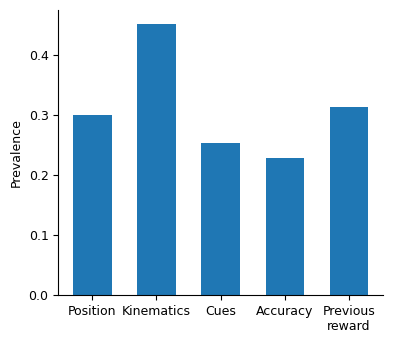

In [ ]:
#09-May-26, added prevalence figure
feature_count={"Position": 91, "Kinematics": 137, "Cues": 77, "Accuracy": 69, "Previous\nreward": 95}
tot_neurons=303
feature_names=list(feature_count.keys())
prevalence=[v/ tot_neurons for v in feature_count.values()]
plt.figure(figsize=(4, 3.5))
plt.rcParams.update({'font.size':9,'font.family': 'DejaVu Sans'})
plt.bar(feature_names, prevalence, width=0.6)
plt.ylabel("Prevalence")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("feature_prevalence.tiff", dpi=600, bbox_inches='tight')
plt.show()

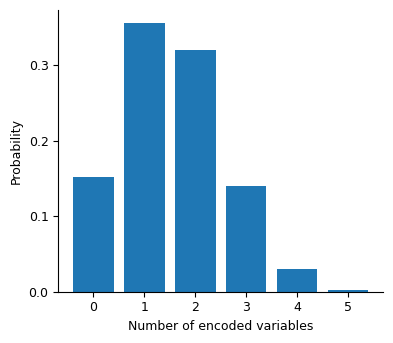

In [ ]:
#09-May-26, added probability figure

k_values1c=[]
probabilities1c=[]

for k in range(0, len(feature_probs)+1):
    p_k, expected = probability_k_features(k, feature_probs, n_neurons=303)

    k_values1c.append(k)
    probabilities1c.append(p_k)

plt.figure(figsize=(4,3.5))

plt.bar(k_values1c, probabilities1c)
plt.rcParams.update({'font.size': 9, 'font.family': 'DejaVu Sans'})
plt.xlabel("Number of encoded variables")
plt.ylabel("Probability")
#plt.title("Probability of k\nactive features")
plt.xticks(k_values1c)
plt.yticks(np.arange(0, 0.37, 0.1))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("num_encoded_var.tiff", dpi=600, bbox_inches='tight')
plt.show()

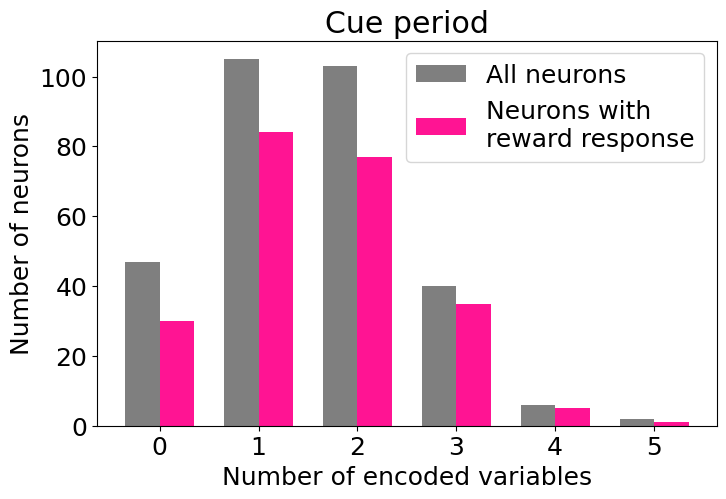

In [ ]:
#07-May-26, reproduced Fig. 3b from Engelhard et al., 2019.
observed_cue3b=[47, 105, 103, 40, 6, 2]
observed_reward3b=[30, 84, 77, 35, 5, 1]

k_values3b=list(range(len(feature_probs)+1))
x=np.arange(len(k_values3b))
width=0.35

plt.figure(figsize=(8,5))
plt.rcParams.update({'font.size': 18})

plt.xlabel("Number of encoded variables")
plt.ylabel("Number of neurons")
plt.title("Cue period")
plt.bar(x-width/2, observed_cue3b, width,color='tab:gray', label="All neurons")
plt.bar(x+width/2, observed_reward3b, width, color='deeppink', label="Neurons with\nreward response")
plt.xticks(x, k_values3b)
plt.legend()

plt.show()

In [ ]:
#07-May-26, calculated the observed and expected distributions
#for all cue-period neurons (n=303)
k_prob1={}
for k in range(len(feature_probs)+1): #k=0,1,2,3,4,5
    p_k,_= probability_k_features(k, feature_probs, n_neurons=303)
    k_prob1[k] = p_k
observed_counts1={0:47, 1:105, 2:103, 3:40, 4:6, 5:2}
n_reward1=303

def binom_pmf(n, k, p):
    return comb(n, k)*(p**k)*((1-p)**(n-k))
def binom_right_tail(n, k_obs, p):
    total1=0.0
    for k in range(k_obs, n+1):
      total1+=binom_pmf(n, k, p)
    return total1

observed_values1=[]
expected_values1=[]
p_value_t1=[]
print(f"{'k':<3} {'observed':<10} {'expected':<10} {'p(x>=obs)'}")
for k in range(len(feature_probs)+1):
   p,_=probability_k_features(k, feature_probs, n_neurons=303)
   observed=observed_counts1[k]
   expected=n_reward1*p
   tail_prob=binom_right_tail(n_reward1, observed, p)
   observed_values1.append(observed)
   expected_values1.append(expected)
   p_value_t1.append(tail_prob)


   print(f"{k:<3} {observed:<10} {expected:<10.2f} {tail_prob:<12.4f}")

#10-May-26, added Kolmogorov-Smirnov test
ks_statistic, ks_p_value = ks_2samp(observed_values1,expected_values1,alternative='two-sided')

#15-May-26, added geometricmean
geo_mean_t1=gmean(p_value_t1)
print(f"Geometric mean: {geo_mean_t1:.4f}")



print("\nTwo-sample Kolmogorov-Smirnov test:")
print(f"KS statistic = {ks_statistic:.4f}")
print(f"p-value = {ks_p_value:.4f}")

k   observed   expected   p(x>=obs)
0   47         45.93      0.4561      
1   105        107.78     0.6513      
2   103        97.15      0.2538      
3   40         42.39      0.6785      
4   6          9.00       0.8880      
5   2          0.75       0.1720      
Geometric mean: 0.4455

Two-sample Kolmogorov-Smirnov test:
KS statistic = 0.1667
p-value = 1.0000


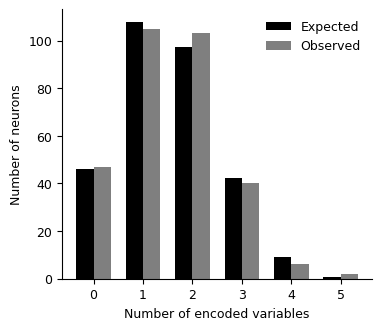

In [ ]:
#07-May-26, generated "number of encoded variables to all neurons" figure
k_values=list(range(len(feature_probs)+1))
observed_all_neurons=[observed_counts1[k] for k in k_values]
expected_all_neurons=[]
for k in k_values:
  p2, _=probability_k_features(k, feature_probs, n_neurons=303)
  expected_all_neurons.append(303*p2)

x=np.arange(len(k_values))
width=0.35
plt.rcParams.update({'font.size': 9,'font.family': 'DejaVu Sans'})
plt.figure(figsize=(4, 3.5))
plt.bar(x-width/2, expected_all_neurons, width, color='k', label="Expected")
plt.bar(x+width/2, observed_all_neurons, width, color='tab:gray', label="Observed")
plt.xlabel("Number of encoded variables")
plt.ylabel("Number of neurons")
#plt.title("All neurons")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(x, k_values)
plt.legend(frameon=False)
plt.savefig("all_neurons_Ex_Ob.tiff", dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
#07-May-26, calculated the probability of k features active in reward-responsive neurons
pink= probability_k_features(k, feature_probs, n_neurons=232)
for k in range (0, len(feature_probs)+1):
  p_k, expected=probability_k_features(k, feature_probs, n_neurons=232)
  print(f"Probability of {k} features active: {p_k:.6f}, expected neurons ={expected:.2f}")

Probability of 0 features active: 0.151572, expected neurons =35.16
Probability of 1 features active: 0.355717, expected neurons =82.53
Probability of 2 features active: 0.320630, expected neurons =74.39
Probability of 3 features active: 0.139910, expected neurons =32.46
Probability of 4 features active: 0.029707, expected neurons =6.89
Probability of 5 features active: 0.002464, expected neurons =0.57


In [ ]:
#07-May-26, calculated the observed and expected distributions
# for reward-responsive cue-period neurons (n=232)
k_probs={}
for k in range(len(feature_probs)+1): #k=0,1,2,3,4,5
    p_k,_= probability_k_features(k, feature_probs, n_neurons=303)
    k_probs[k] = p_k
observed_counts={0:30, 1:84, 2:77, 3:35, 4:5, 5:1}
n_reward=232

def binom_pmf(n, k, p):
    return comb(n, k)*(p**k)*((1-p)**(n-k))
def binom_right_tail(n, k_obs, p):
    total=0.0
    for k in range(k_obs, n+1):
      total+=binom_pmf(n, k, p)
    return total
rows=[]
observed_values2=[]
expected_values2=[]
p_value_t2=[]
for k in range(len(feature_probs)+1):
   p2,_=probability_k_features(k, feature_probs, n_neurons=303)
   observed2=observed_counts[k]
   expected2=n_reward*p2
   tail_prob2=binom_right_tail(n_reward, observed2, p2)
   rows.append({"k": k, "Observed": observed2, "Expected": round(expected2, 2), "p(x>=obs)":round(tail_prob2, 2)})
   observed_values2.append(observed2)
   expected_values2.append(expected2)
   p_value_t2.append(tail_prob2)
df=pd.DataFrame(rows)
print(df.to_string(index=False))

#10-May-26, added Kolmogorov-Smirnov test
ks_statistic, ks_p_value = ks_2samp(observed_values2,expected_values2,alternative='two-sided')

#15-May-26, added geometricmean
geo_mean_t2=gmean(p_value_t2)
print(f"Geometric mean: {geo_mean_t2:.4f}")



print("\nTwo-sample Kolmogorov-Smirnov test:")
print(f"KS statistic = {ks_statistic:.4f}")
print(f"p-value = {ks_p_value:.4f}")

 k  Observed  Expected  p(x>=obs)
 0        30     35.16       0.85
 1        84     82.53       0.44
 2        77     74.39       0.38
 3        35     32.46       0.34
 4         5      6.89       0.82
 5         1      0.57       0.44
Geometric mean: 0.5101

Two-sample Kolmogorov-Smirnov test:
KS statistic = 0.1667
p-value = 1.0000


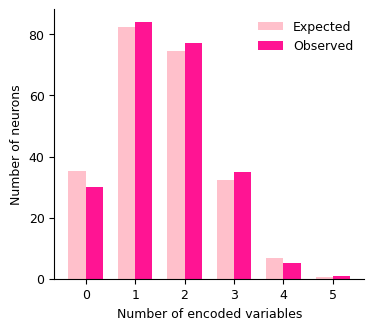

In [ ]:
#07-May-26, generated "number of encoded variables to the reward responsive subset" figure
k_values=list(range(len(feature_probs)+1))
observed_reward_response=[observed_counts[k] for k in k_values]
expected_reward_response=[]
for k in k_values:
  p3, _=probability_k_features(k, feature_probs, n_neurons=232)
  expected_reward_response.append(232*p3)

x=np.arange(len(k_values))
width=0.35
plt.rcParams.update({'font.size':9,'font.family': 'DejaVu Sans'})
plt.figure(figsize=(4,3.5))
plt.bar(x-width/2, expected_reward_response, width, color='pink', label="Expected")
plt.bar(x+width/2, observed_reward_response, width, color='deeppink', label="Observed")
plt.xlabel("Number of encoded variables")
plt.ylabel("Number of neurons")
#plt.title("Reward responsive neurons")
plt.xticks(x, k_values)
plt.yticks(np.arange(0, max(observed_reward_response), 20))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(frameon=False)
plt.savefig("reward_responsive_Ex_Ob.tiff", dpi=600, bbox_inches='tight')
plt.show()